
## Exploratory data analysis


### Data understanding and assessment
Before any analysis, we need to understand what we have: data types, missing values, duplicates, and basic distributions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('./data/hotel_bookings.csv')

In [ ]:
print('Dataset overview')
print(f'Rows : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'Date range : Jul 2015 - Aug 2017') # from paper abstract
print(f'Hotels : {df["hotel"].unique()}')
print()
print(df.dtypes)

Dataset overview
Rows : 119,390
Columns : 32
Date range : Jul 2015 - Aug 2017
Hotels : <ArrowStringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str


- arrival_date_month is categorical, probably convert it to an int (map the month to a number), check the values if they're valid
-  children is a float, needs to be converted to int
- check all the categorical features and explore them for feature engineering

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': (missing / len(df) * 100).round(2),
    'dtype': df[missing.index].dtypes
}).sort_values('missing_pct', ascending=False)

print('Missing values')
print(missing)

Missing values
          missing_count  missing_pct    dtype
company          112593        94.31  float64
agent             16340        13.69  float64
country             488         0.41      str
children              4         0.00  float64


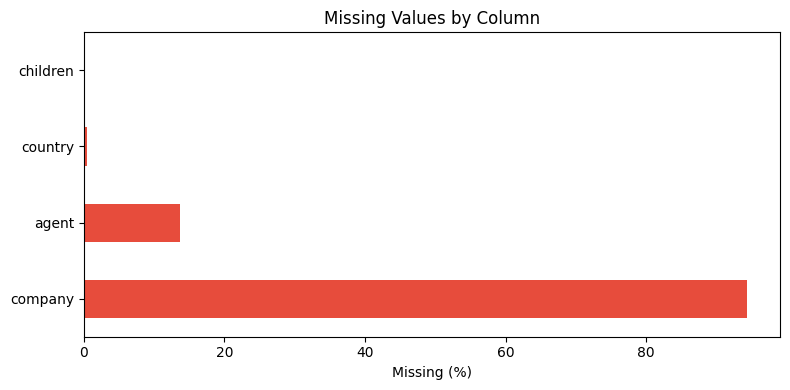

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
missing['missing_pct'].plot(kind='barh', ax=ax, color='#E74C3C')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.savefig('./eda_visuals/missing_values.png', bbox_inches='tight')
plt.show()

Accordign to the source of the dataset "company" is the company/entity that made the booking or responsible for paying the booking, and "agent" is the travel agency that made the booking. They both have "NULL" values; however, these do not represent a missing value but rather a "not applicable "value". So of a guest made a booking independently, then agent and company will both contain a "NULL" value. Dropping the column would not be the way to go for this.

In [8]:
# descriptive statistics
print('Descriptive statistics')
df.describe().T.round(2)

Descriptive statistics


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.37,0.48,0.00,0.00,0.00,1.0,1.0
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0


- adr cannot be negative because its a spending rate, definitly has outliers because why is max 5.4k
- company and agent are IDs so they shouldnt be treated as numbers -> need to convert them to str
- seems to be outliers in days_in_waiting becauyse the 75% is 0 and max is 391, same thing for booking_changes
- adults max also seems to be an outlier because 55 is very high for one booking
- previous_bookings_not_canceled has the value 0 if the user didnt book before, so i think this needs to be checked out

what to check for outliers:
- lead_time, stays_in_weekend_nights, stays_in_week_nights, adults, children, babies, previous_cancellations (seems to be an important feature), previous_bookings_not_canceled, booking_changes

### Distribution visualization

In [31]:
outlier_features = [
    'adr', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list'
]

In [32]:
summary_rows = []
for col in outlier_features:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low_fence = q1 - 1.5 * iqr
    high_fence = q3 + 1.5 * iqr
    outlier_mask = (s < low_fence) | (s > high_fence)

    summary_rows.append({
        'feature': col,
        'n': int(s.shape[0]),
        'zeros_%': round((s.eq(0).mean()) * 100, 2),
        'negatives_n': int((s < 0).sum()),
        'min': round(s.min(), 2),
        'p99': round(s.quantile(0.99), 2),
        'max': round(s.max(), 2),
        'iqr_low_fence': round(low_fence, 2),
        'iqr_high_fence': round(high_fence, 2),
        'iqr_outliers_n': int(outlier_mask.sum()),
        'iqr_outliers_%': round(outlier_mask.mean() * 100, 2),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('iqr_outliers_%', ascending=False)
display(summary_df)

,feature,n,zeros_%,negatives_n,min,p99,max,iqr_low_fence,iqr_high_fence,iqr_outliers_n,iqr_outliers_%
4,adults,119390,0.34,0,0.00,3.0,55.0,2.00,2.00,29710,24.88
9,booking_changes,119390,84.86,0,0.00,3.0,21.0,0.00,0.00,18076,15.14
5,children,119386,92.80,0,0.00,2.0,10.0,0.00,0.00,8590,7.20
7,previous_cancellations,119390,94.57,0,0.00,1.0,26.0,0.00,0.00,6484,5.43
0,adr,119390,1.64,1,-6.38,252.0,5400.0,-15.77,211.06,3793,3.18
10,days_in_waiting_list,119390,96.90,0,0.00,75.0,391.0,0.00,0.00,3698,3.10
8,previous_bookings_not_canceled,119390,96.97,0,0.00,3.0,72.0,0.00,0.00,3620,3.03
3,stays_in_week_nights,119390,6.40,0,0.00,10.0,50.0,-2.00,6.00,3354,2.81
1,lead_time,119390,5.31,0,0.00,444.0,737.0,-195.00,373.00,3005,2.52
6,babies,119390,99.23,0,0.00,0.0,10.0,0.00,0.00,917,0.77


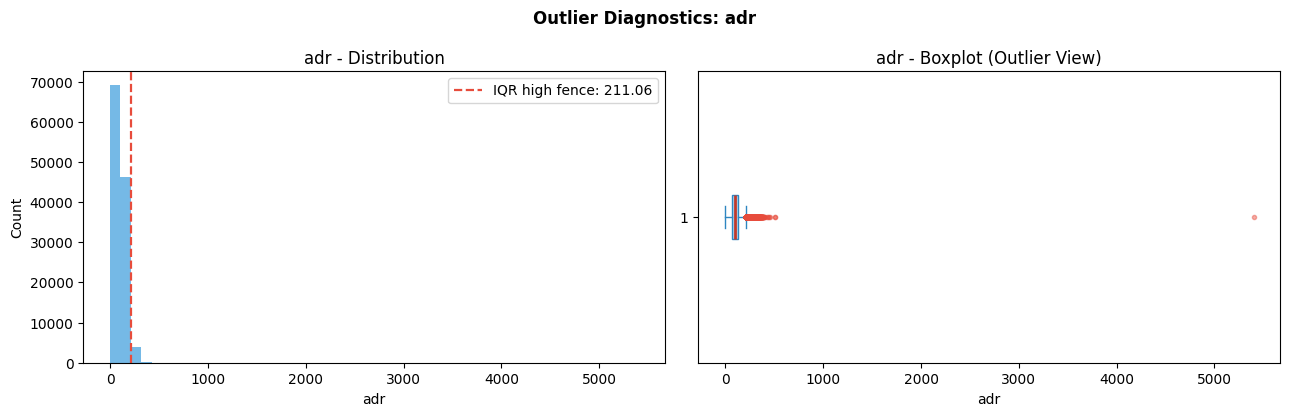

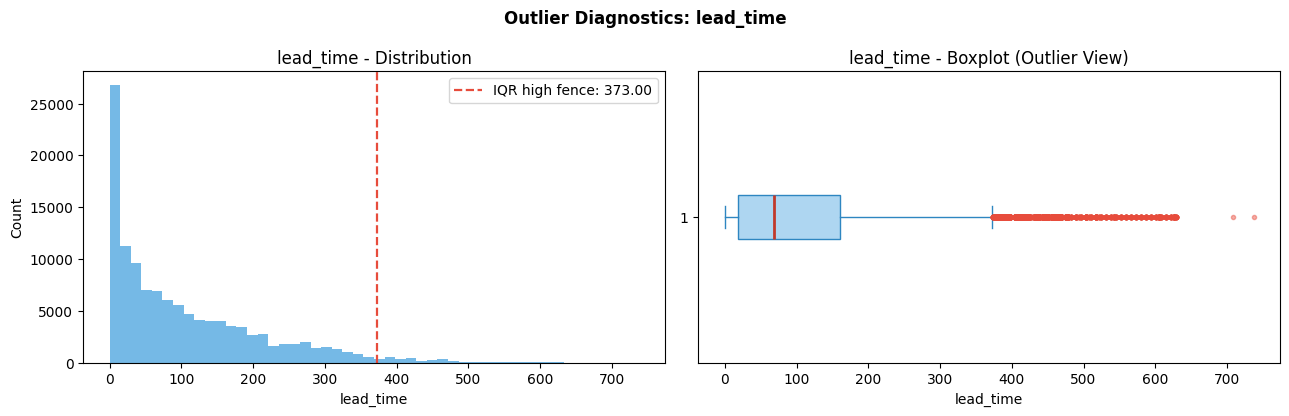

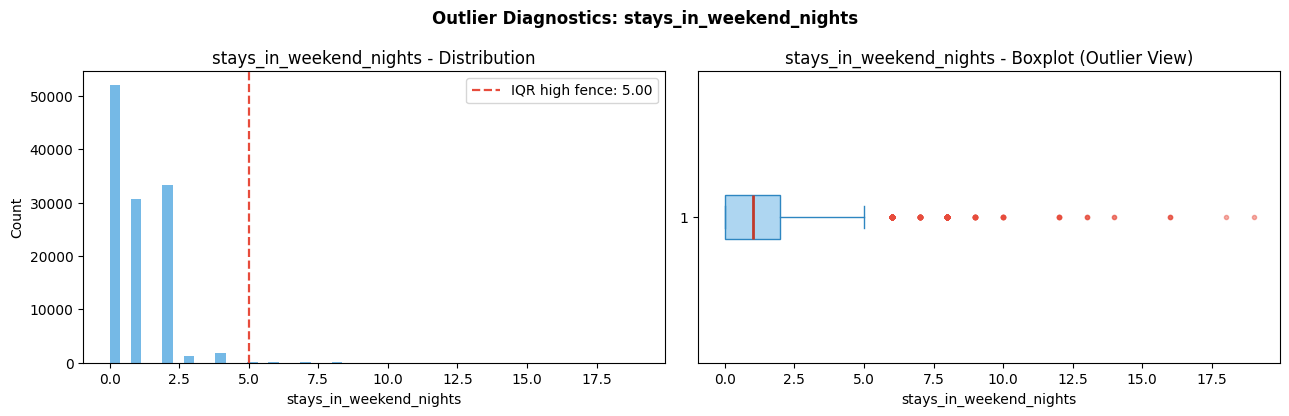

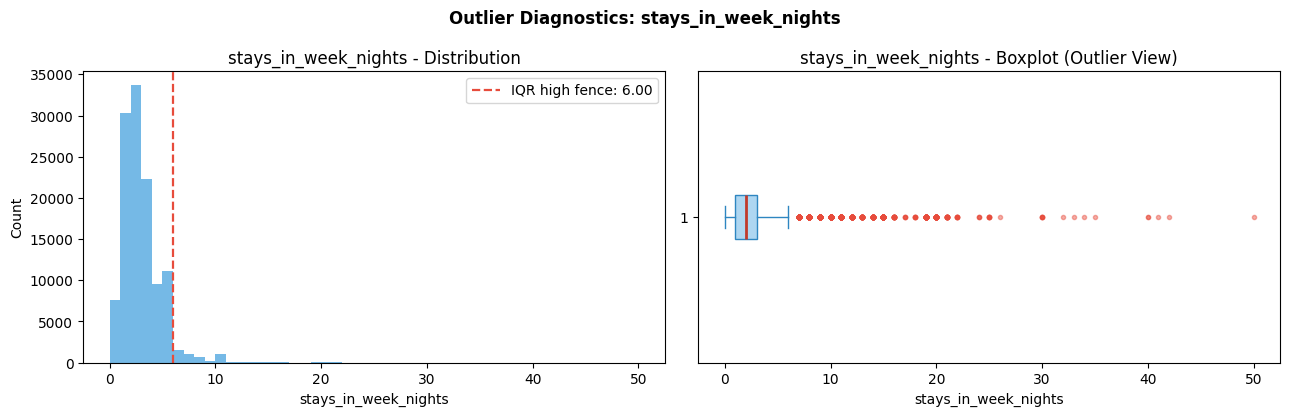

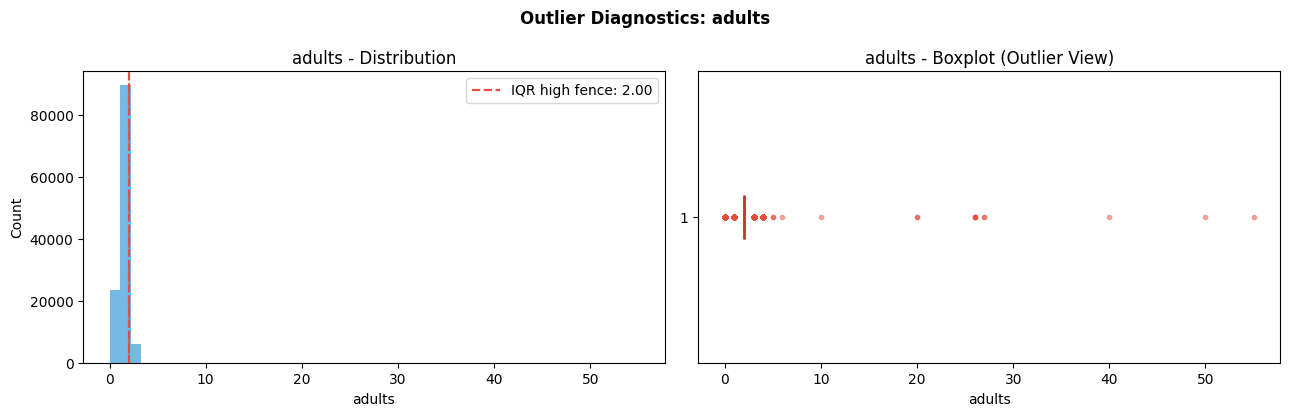

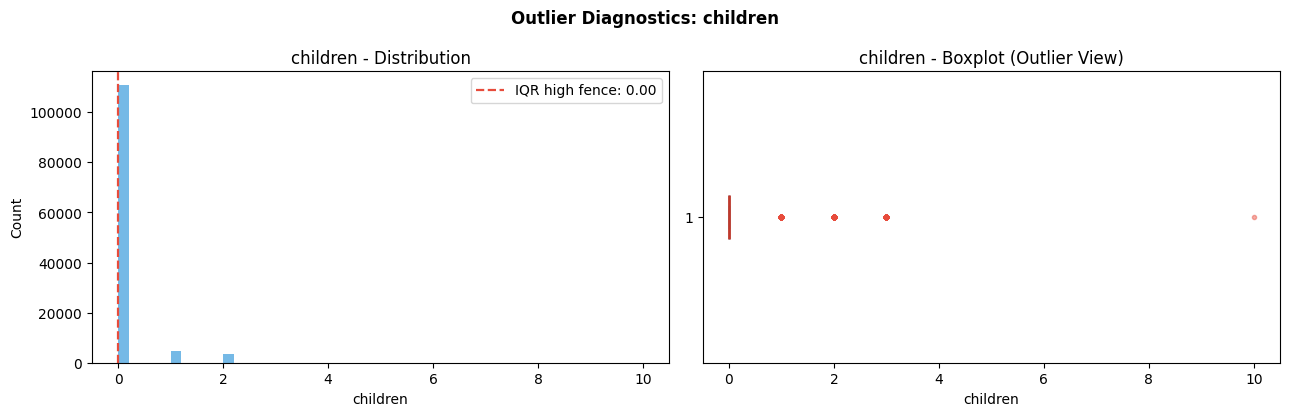

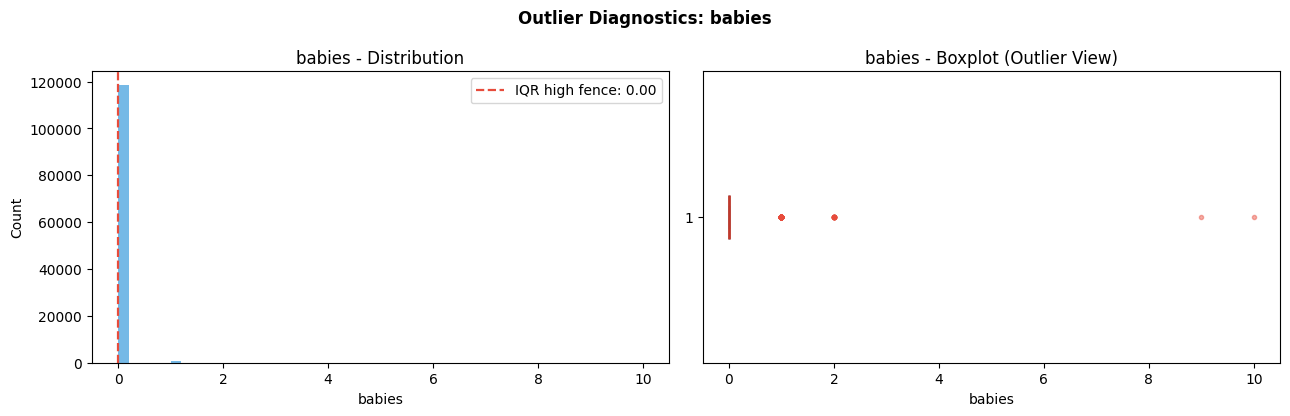

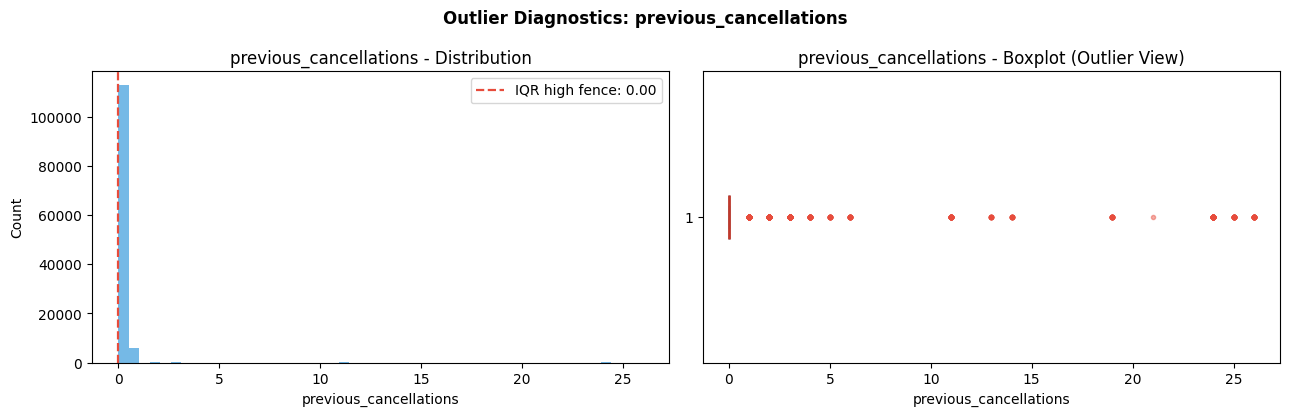

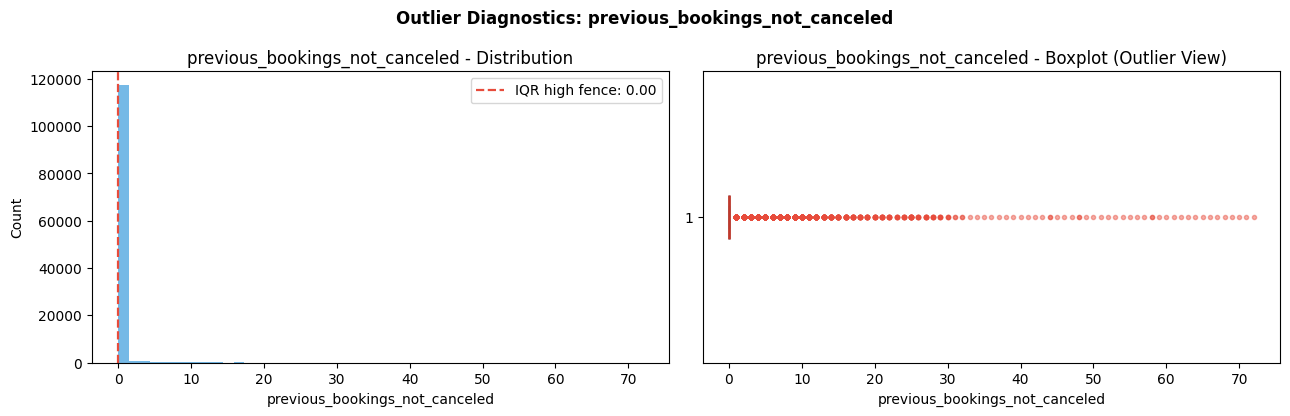

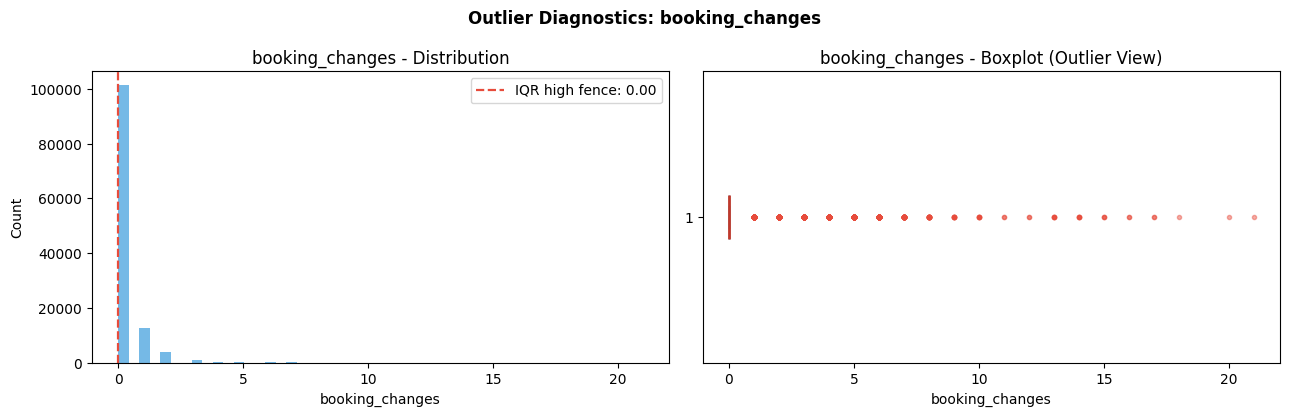

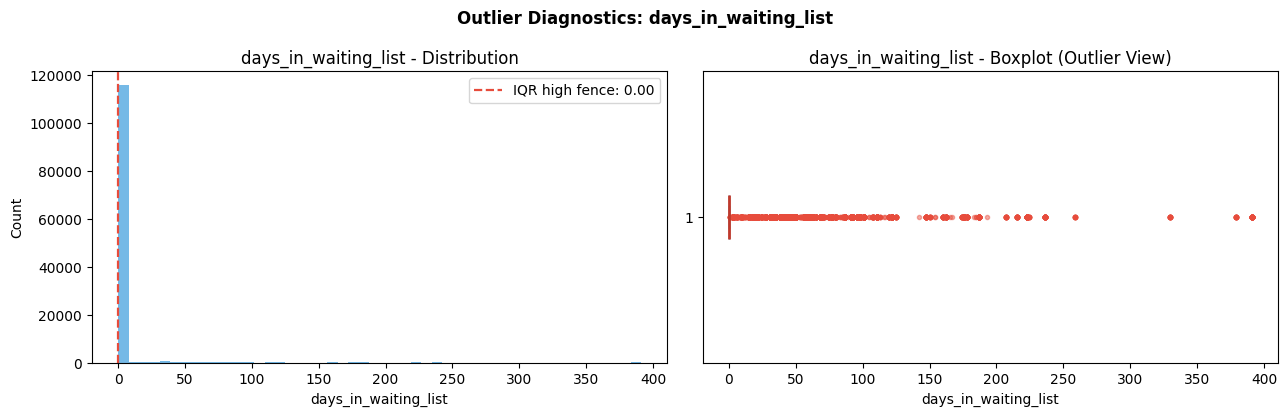

In [ ]:
def visualize_outliers(df, col, name):
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low_fence = q1 - 1.5 * iqr
    high_fence = q3 + 1.5 * iqr

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

    axes[0].hist(s, bins=50, color='#5DADE2', alpha=0.85)
    axes[0].axvline(high_fence, color='#E74C3C', linestyle='--', linewidth=1.6, label=f'IQR high fence: {high_fence:.2f}')
    if low_fence > s.min():
        axes[0].axvline(low_fence, color='#E74C3C', linestyle='--', linewidth=1.2)
    axes[0].set_title(f'{col} - Distribution')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[0].legend(loc='upper right')

    axes[1].boxplot(s, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='#2E86C1'),
                    medianprops=dict(color='#C0392B', linewidth=2),
                    whiskerprops=dict(color='#2E86C1'),
                    capprops=dict(color='#2E86C1'),
                    flierprops=dict(marker='o', markersize=3, markerfacecolor='#E74C3C', markeredgecolor='#E74C3C', alpha=0.45))
    axes[1].set_title(f'{col} - Boxplot (Outlier View)')
    axes[1].set_xlabel(col)

    plt.suptitle(f'Outlier Diagnostics: {col}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'./eda_visuals/{name}', bbox_inches='tight')
    plt.show()

for col in outlier_features:
    name = f"{col}_outliers.png"
    visualize_outliers(df, col, name)


### Data cleaning
According to the source, the following needs to be accounted for:
- `children`, `country`, `agent`, `company` have real null values
- `NULL` strings in `agent` and `company` mean "not applicable" not missing
- Rows with 0 adults, 0 children, and 0 babies are phantom bookings
- `adr` has negative values which are data errors

In [292]:
# fix children and country null values --> null children = 0 and null country = 'Unknown'
df_clean = df.copy()
df_clean['children'] = df_clean['children'].fillna(0).astype(int)
df_clean['country'] = df_clean['country'].fillna('Unknown')

print(f'children nulls filled: {df["children"].isnull().sum()}') 
print(f'country nulls filled : {df["country"].isnull().sum()}')

# fix the agent and company values, if agent is null then its a direct booking from the customer so null gets replaced with direct
# if company is null then it means the booking was not made through a company so null gets replaced with none
# handling na
df_clean['agent']   = df_clean['agent'].fillna('Direct').astype(str)
df_clean['company'] = df_clean['company'].fillna('None').astype(str)
# handiling "null"
df_clean['agent'] = df_clean['agent'].replace(['NULL', 'null', 'Null'], np.nan).fillna('Direct').astype(str)
df_clean['company'] = df_clean['company'].replace(['NULL', 'null', 'Null'], np.nan).fillna('None').astype(str)

# make sure theyre all str
df_clean[['agent', 'company']] = df_clean[['agent', 'company']].astype(str)

# check how many phantom bookings there are and remove 
phantom_mask = (df_clean['adults'] == 0) & (df_clean['children'] == 0) & (df_clean['babies'] == 0)
print(f'Phantom bookings removed: {phantom_mask.sum()}')
df_clean = df_clean[~phantom_mask]

# adr is average daily rates, calculated as dividing the sum of all lodging transactions by the total number of staying nights
# this value cannot be negative so negative values are data errors that need to be removed
neg_adr = (df_clean['adr'] < 0).sum()
print(f'Negative ADR rows removed: {neg_adr}')
df_clean = df_clean[df_clean['adr'] >= 0]

children nulls filled: 4
country nulls filled : 488
Phantom bookings removed: 180
Negative ADR rows removed: 1


In [293]:
# saving this for baseline testing 
df_clean.to_csv('./data/hotel_bookings_initial.csv', index=False)

#### Handling outliers

Winsorization

In [294]:
outliers_fixed = []

In [295]:
# -----------cap adr at 99.5 percentile
adr_cap = df_clean['adr'].quantile(0.995)
extreme_adr = (df_clean['adr'] > adr_cap).sum()
print(f'Extreme ADR rows to winsorize (>{adr_cap:.0f}): {extreme_adr}')
# flag for later analysis if needed
df_clean['adr_was_capped'] = (df_clean['adr'] > adr_cap).astype(int)
df_clean['adr'] = df_clean['adr'].clip(upper=adr_cap)
outliers_fixed.append('adr')

# ------------lead_time cap 98 percentile: 393 days before the booking
lead_cap = df_clean['lead_time'].quantile(0.98)
print(f'Extreme lead time rows to winsorize (>{lead_cap:.0f}): {(df_clean['lead_time'] > lead_cap).sum()}')
# flag
df_clean['lead_time_was_capped'] = (df_clean['lead_time'] > lead_cap).astype(int)
df_clean['lead_time'] = df_clean['lead_time'].clip(upper=lead_cap)
# log transform to reduce skew
df_clean['lead_time_log'] = np.log1p(df_clean['lead_time'])
outliers_fixed.append('lead_time')
outliers_fixed.append('lead_time_log')

# -----------weekend nights stays cap at 99.5 percentile
weekend_cap = df_clean['stays_in_weekend_nights'].quantile(0.995)
print(f'Extreme weekend stay rows to winsorize (>{weekend_cap:.0f}): {(df_clean['stays_in_weekend_nights'] > weekend_cap).sum()}')
# flag
df_clean['stays_weekend_was_capped'] = (df_clean['stays_in_weekend_nights'] > weekend_cap).astype(int)
df_clean['stays_in_weekend_nights'] = df_clean['stays_in_weekend_nights'].clip(upper=weekend_cap)
outliers_fixed.append('stays_in_weekend_nights')

# -----------week nights stays cap at 99.5 percentile
week_cap = df_clean['stays_in_week_nights'].quantile(0.995)
print(f'Extreme weekly stay rows to winsorize (>{week_cap:.0f}): {(df_clean['stays_in_week_nights'] > week_cap).sum()}')
# flag
df_clean['stays_week_was_capped'] = (df_clean['stays_in_week_nights'] > week_cap).astype(int)
df_clean['stays_in_week_nights'] = df_clean['stays_in_week_nights'].clip(upper=week_cap)
outliers_fixed.append('stays_in_week_nights')

# -----------adults cap at 6
ADULTS_MAX = 6
print(f'Extreme adult rows to winsorize (>{ADULTS_MAX}): {(df_clean['adults'] > ADULTS_MAX).sum()}')
# flag
df_clean['adults_was_capped'] = (df_clean['adults'] > ADULTS_MAX).astype(int)
df_clean['adults'] = df_clean['adults'].clip(upper=ADULTS_MAX)
outliers_fixed.append('adults')

# -----------children cap at 3
CHILDREN_MAX = 3
print(f'Extreme children rows to winsorize (>{CHILDREN_MAX}): {(df_clean['children'] > CHILDREN_MAX).sum()}')
# flag
df_clean['has_children'] = (df_clean['children'] > 0).astype(int)
df_clean['children_was_capped'] = (df_clean['children'] > CHILDREN_MAX).astype(int)
df_clean['children'] = df_clean['children'].clip(upper=CHILDREN_MAX)
outliers_fixed.append('children')

# -----------babies cap at 2
BABIES_MAX = 2
print(f'Extreme babies rows to winsorize (>{BABIES_MAX}): {(df_clean['babies'] > BABIES_MAX).sum()}')
# flag
df_clean['has_babies'] = (df_clean['babies'] > 0).astype(int)
df_clean['babies_was_capped'] = (df_clean['babies'] > BABIES_MAX).astype(int)
df_clean['babies'] = df_clean['babies'].clip(upper=BABIES_MAX)
outliers_fixed.append('babies')

# -----------booking changes cap at 99.5 percentile
book_change_cap = df_clean['booking_changes'].quantile(0.995)
print(f'Extreme booking changes rows to winsorize (>{book_change_cap}): {(df_clean["booking_changes"] > book_change_cap).sum()}')
# booking change flag
df_clean['has_booking_changes'] = (df_clean['booking_changes'] > 0).astype(int)
# flag
df_clean['booking_changes_was_capped'] = (df_clean['booking_changes'] > book_change_cap).astype(int)
df_clean['booking_changes'] = df_clean['booking_changes'].clip(upper=book_change_cap)
outliers_fixed.append('booking_changes')

# -----------days in waiting list cap at 99.5 percentile
wait_cap = df_clean['days_in_waiting_list'].quantile(0.995)
print(f'Extreme days in waiting list rows to winsorize (>{wait_cap}): {(df_clean["days_in_waiting_list"] > wait_cap).sum()}')
# flag
df_clean['has_waiting_list'] = (df_clean['days_in_waiting_list'] > 0).astype(int)
df_clean['days_waiting_was_capped'] = (df_clean['days_in_waiting_list'] > wait_cap).astype(int)

df_clean['days_in_waiting_list'] = df_clean['days_in_waiting_list'].clip(upper=wait_cap)
df_clean['days_in_waiting_list_log'] = np.log1p(df_clean['days_in_waiting_list'])
outliers_fixed.append('days_in_waiting_list')
outliers_fixed.append('days_in_waiting_list_log')

Extreme ADR rows to winsorize (>275): 588
Extreme lead time rows to winsorize (>393): 2320
Extreme weekend stay rows to winsorize (>4): 335
Extreme weekly stay rows to winsorize (>10): 394
Extreme adult rows to winsorize (>6): 13
Extreme children rows to winsorize (>3): 1
Extreme babies rows to winsorize (>2): 2
Extreme booking changes rows to winsorize (>4.0): 251
Extreme days in waiting list rows to winsorize (>111.0): 581


For booking history, the problem is that the value 0 (for both cancellation and no cancellation history) can also mean that the person just doesn't have any previous bookings. This makes things ambiguous because if in previous_bookings_not_canceled there is a 0 we don't know if its because theres no history or becasuse the user has cancelled all their previous bookings (red flag they may be likely to cancel this one too).

In [296]:
# keep originals for traceability
df_clean['previous_cancellations_raw'] = df_clean['previous_cancellations']
df_clean['previous_bookings_not_canceled_raw'] = df_clean['previous_bookings_not_canceled']

#-----------previous cancellations cap at 99.8 percentile
prev_cancel_cap = df_clean['previous_cancellations'].quantile(0.998)
print(f'Extreme previous cancellations rows to winsorize (>{prev_cancel_cap}): {(df_clean["previous_cancellations_raw"] > prev_cancel_cap).sum()}')
# flag
df_clean['previous_cancellations_was_capped'] = (df_clean['previous_cancellations_raw'] > prev_cancel_cap).astype(int)
df_clean['previous_cancellations'] = df_clean['previous_cancellations_raw'].clip(upper=prev_cancel_cap)

# flag for cancelation
df_clean['has_prev_cancellations'] = (df_clean['previous_cancellations'] > 0).astype(int)
df_clean['previous_cancellations_log'] = np.log1p(df_clean['previous_cancellations'])
outliers_fixed.append('previous_cancellations')
outliers_fixed.append('previous_cancellations_log')

#-----------previous bookings not canceled cap at 99 percentile
prev_not_cancel_cap = df_clean['previous_bookings_not_canceled'].quantile(0.99)
print(f'Extreme previous bookings not canceled rows to winsorize (>{prev_not_cancel_cap}): {(df_clean["previous_bookings_not_canceled_raw"] > prev_not_cancel_cap).sum()}')
# flag
df_clean['previous_bookings_not_canceled_was_capped'] = (df_clean['previous_bookings_not_canceled_raw'] > prev_not_cancel_cap).astype(int)
df_clean['previous_bookings_not_canceled'] = df_clean['previous_bookings_not_canceled_raw'].clip(upper=prev_not_cancel_cap)

# flag for cancelation
df_clean['has_prev_not_canceled'] = (df_clean['previous_bookings_not_canceled'] > 0).astype(int)
df_clean['previous_bookings_not_canceled_log'] = np.log1p(df_clean['previous_bookings_not_canceled'])
outliers_fixed.append('previous_bookings_not_canceled')
outliers_fixed.append('previous_bookings_not_canceled_log')

# check if theres any history, basically to help with the ambiguous 0 flag
df_clean['has_any_history'] = ((df_clean['previous_cancellations'] + df_clean['previous_bookings_not_canceled']) > 0).astype(int)

# cancellation propensity among known previous bookings
prev_total = df_clean['previous_cancellations'] + df_clean['previous_bookings_not_canceled']
df_clean['prev_cancel_ratio'] = np.where(prev_total > 0, df_clean['previous_cancellations'] / prev_total, 0.0)

Extreme previous cancellations rows to winsorize (>4.0): 221
Extreme previous bookings not canceled rows to winsorize (>3.0): 1162


In [297]:
# summary
flag_cols = [c for c in df_clean.columns if c.endswith('_was_capped')]
print(df_clean[flag_cols].sum().sort_values(ascending=False))


lead_time_was_capped                         2320
previous_bookings_not_canceled_was_capped    1162
adr_was_capped                                588
days_waiting_was_capped                       581
stays_week_was_capped                         394
stays_weekend_was_capped                      335
booking_changes_was_capped                    251
previous_cancellations_was_capped             221
adults_was_capped                              13
babies_was_capped                               2
children_was_capped                             1
dtype: int64


In [298]:
df.shape

(119390, 32)

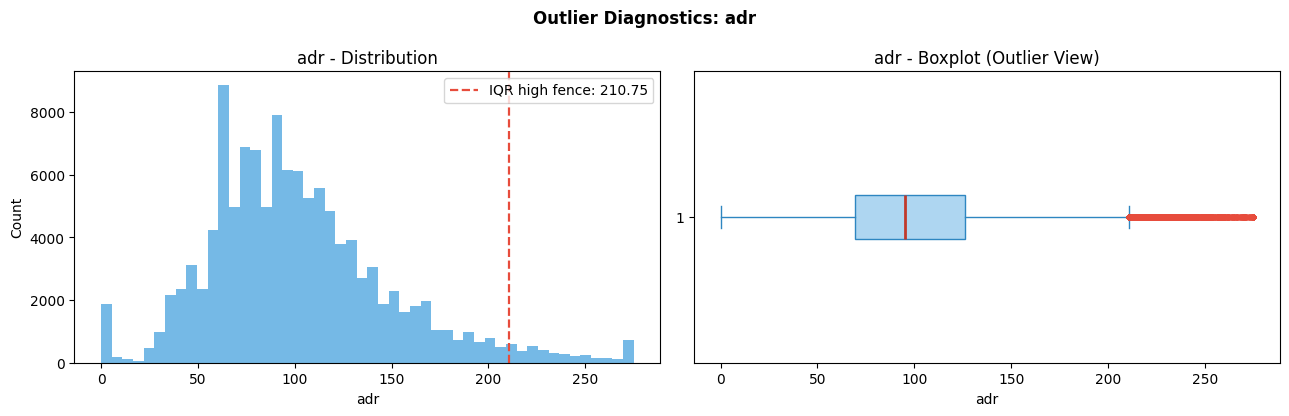

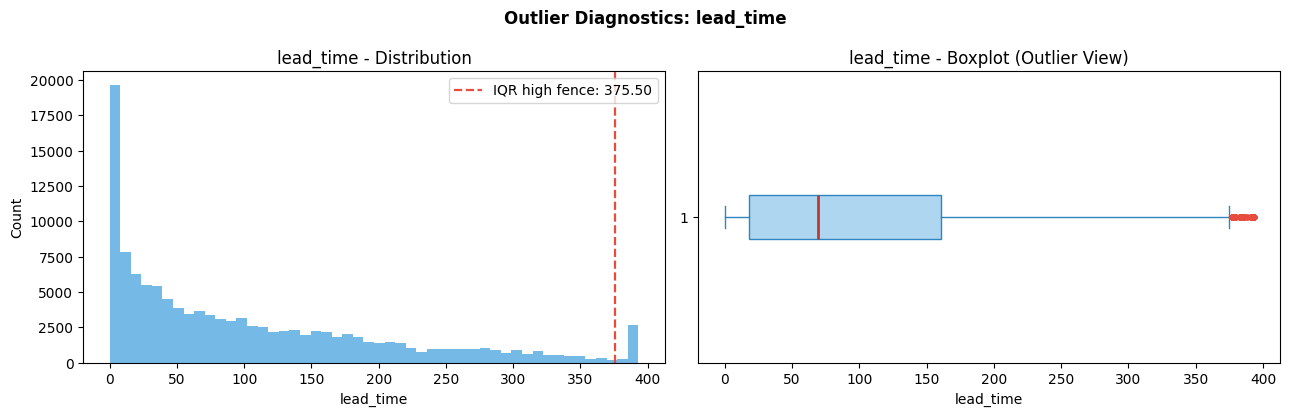

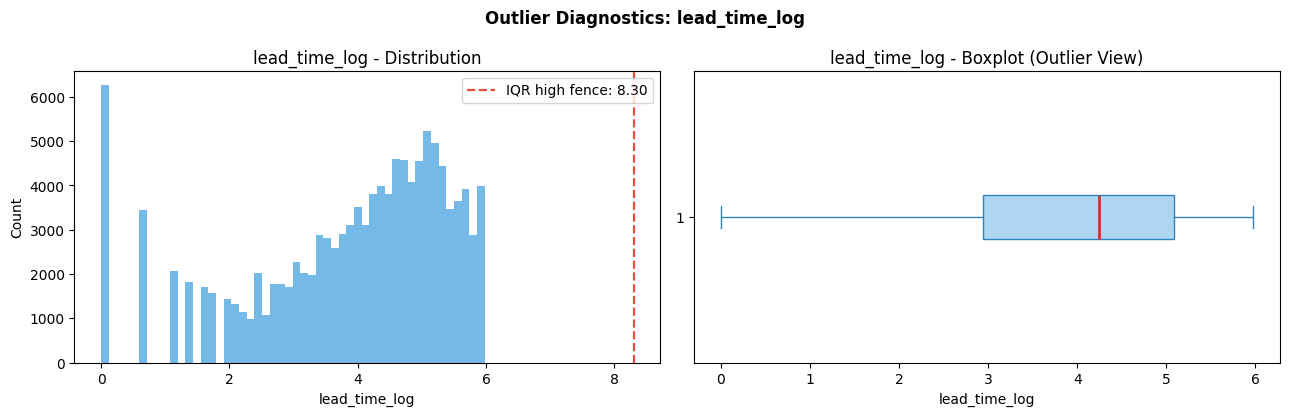

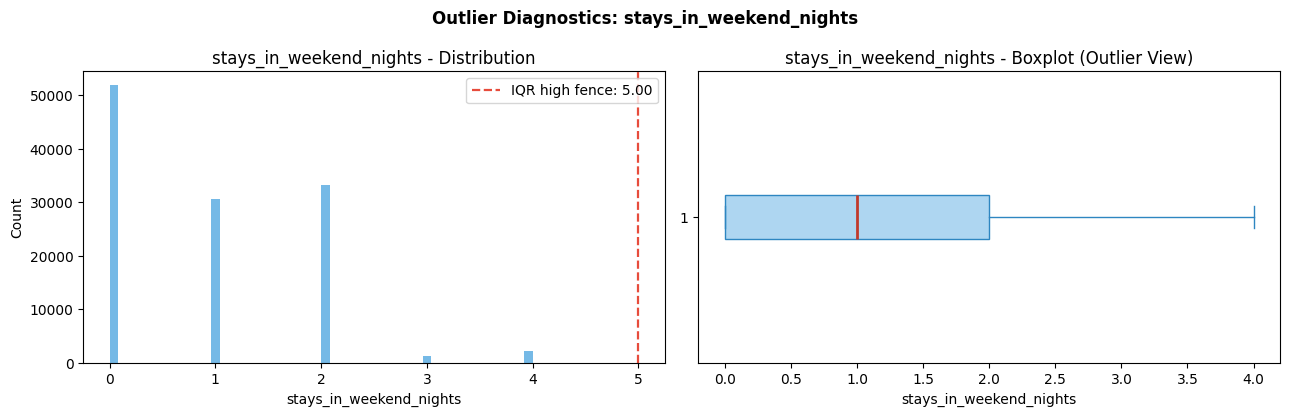

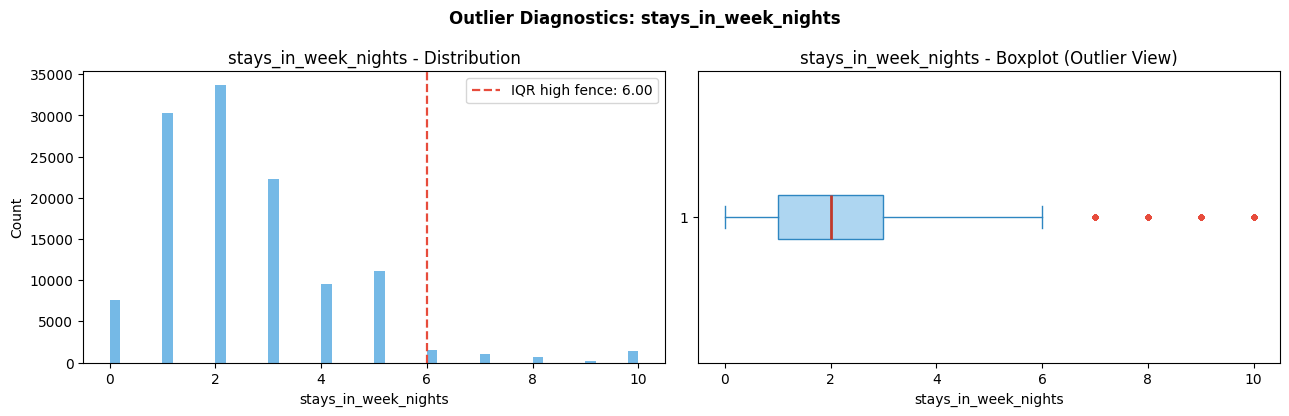

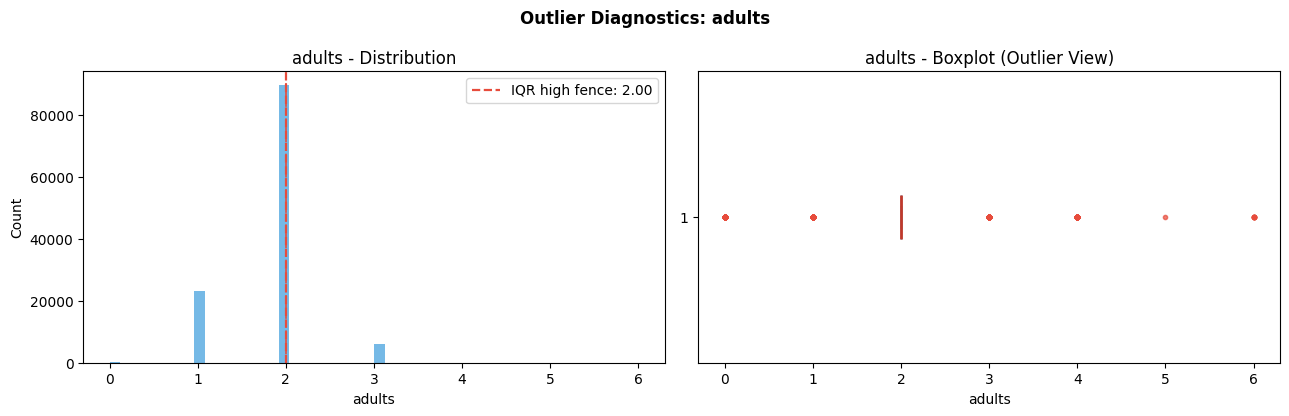

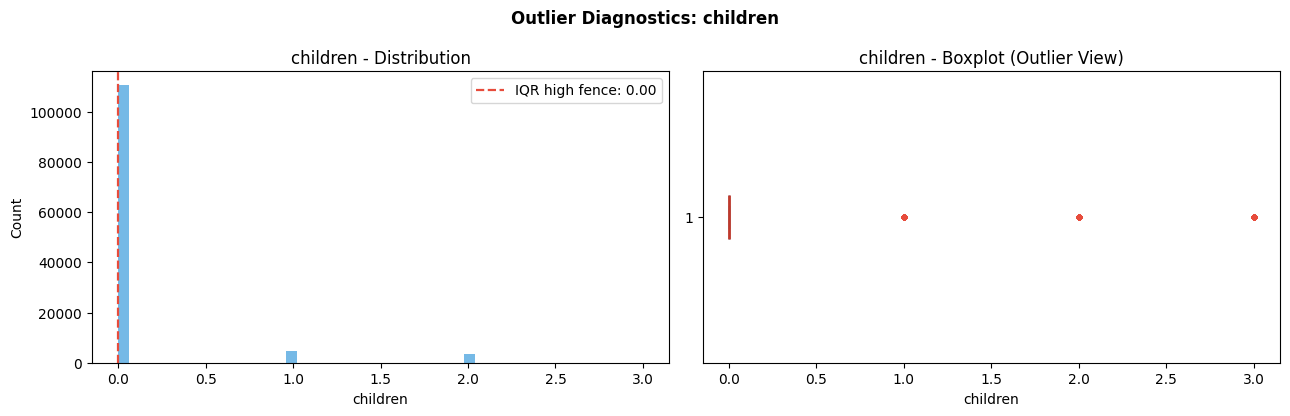

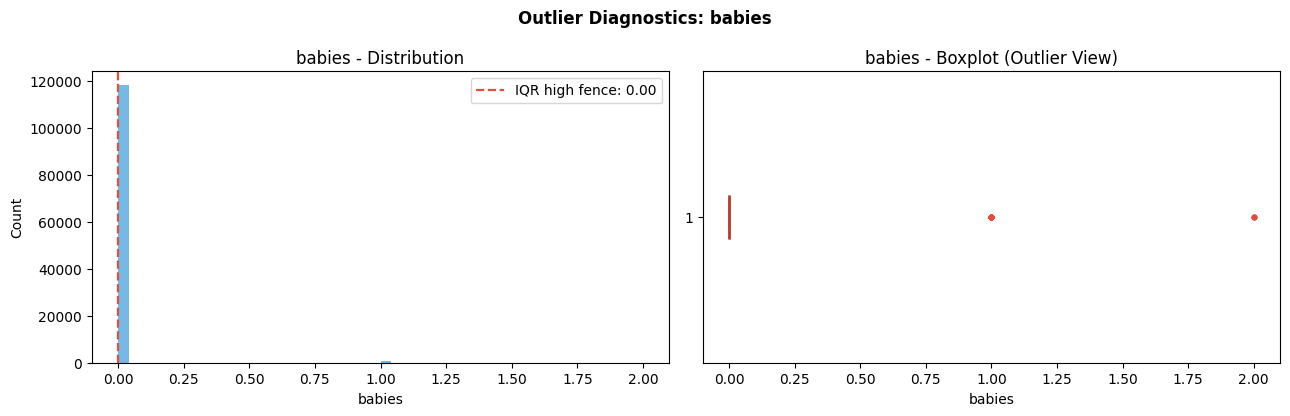

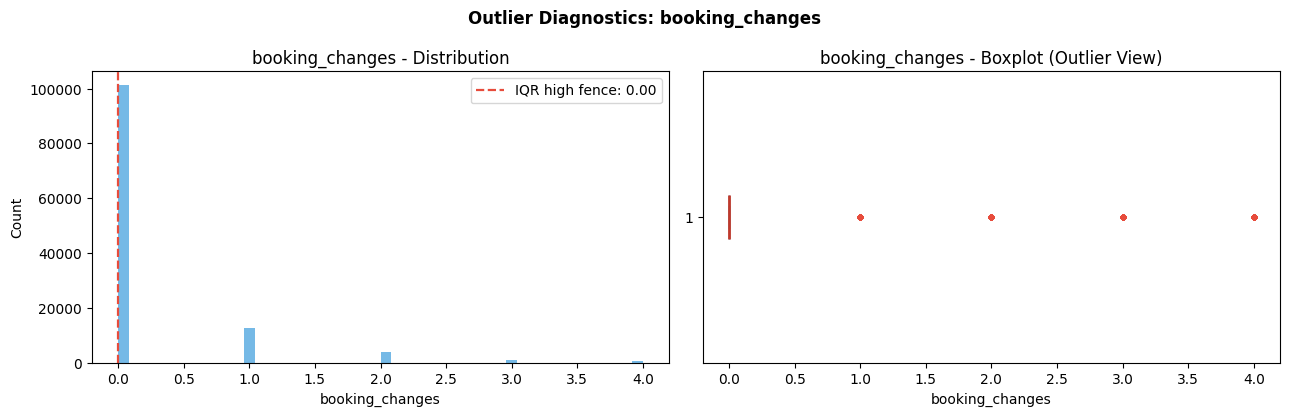

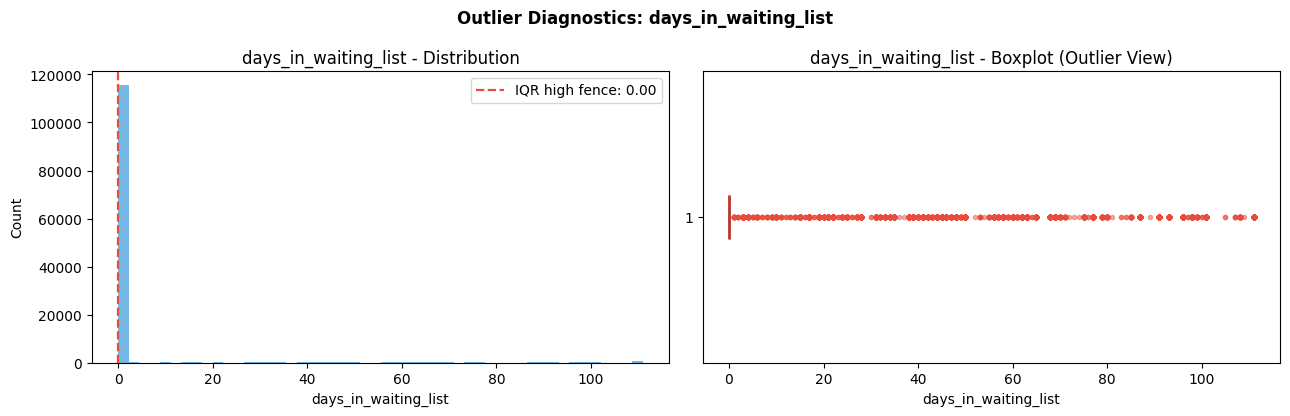

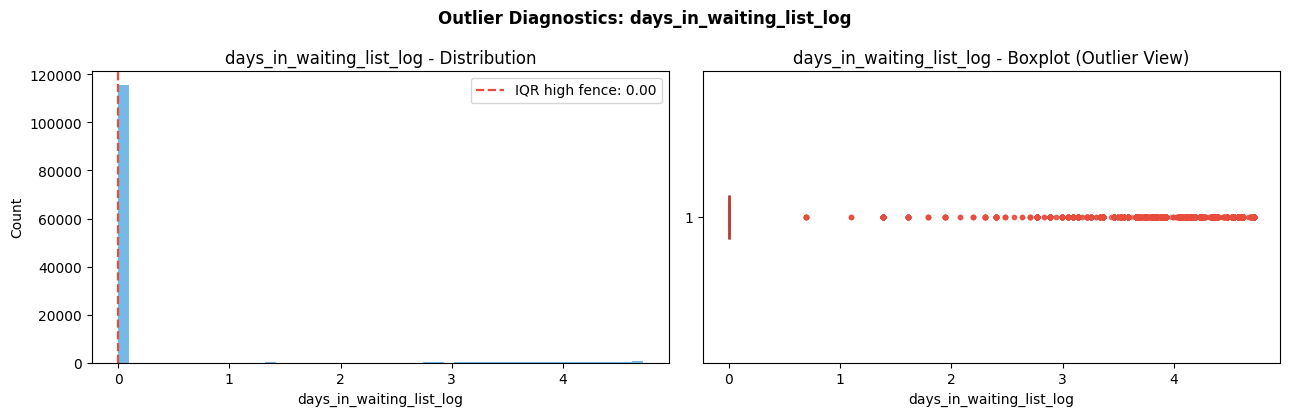

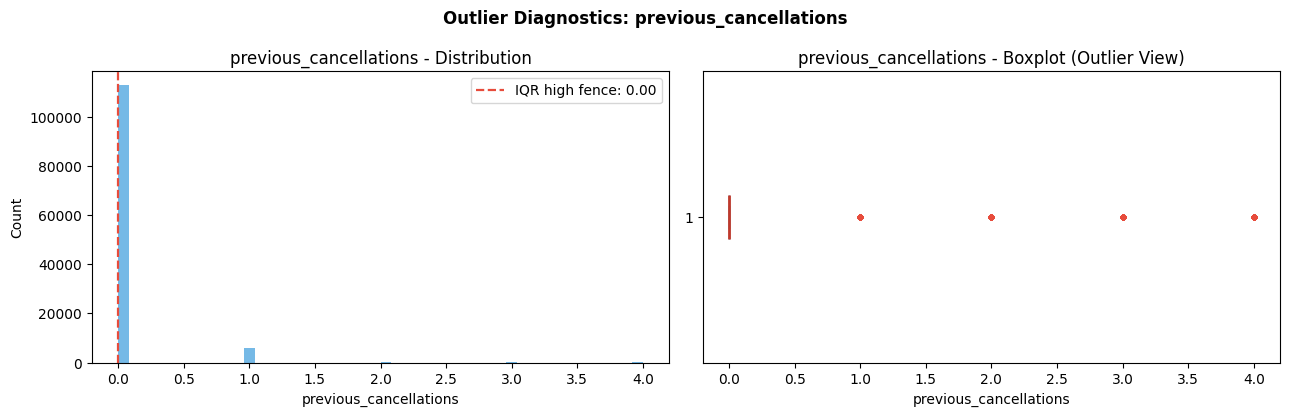

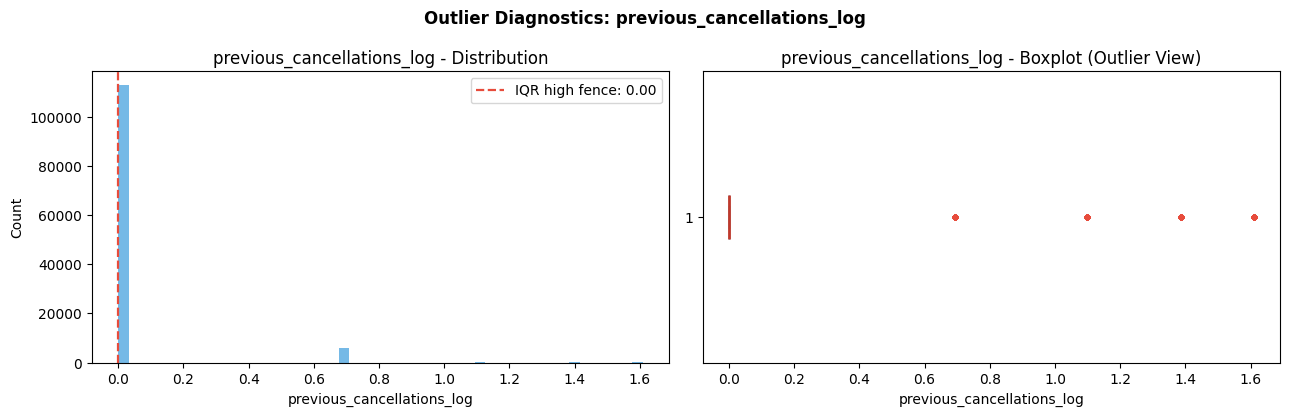

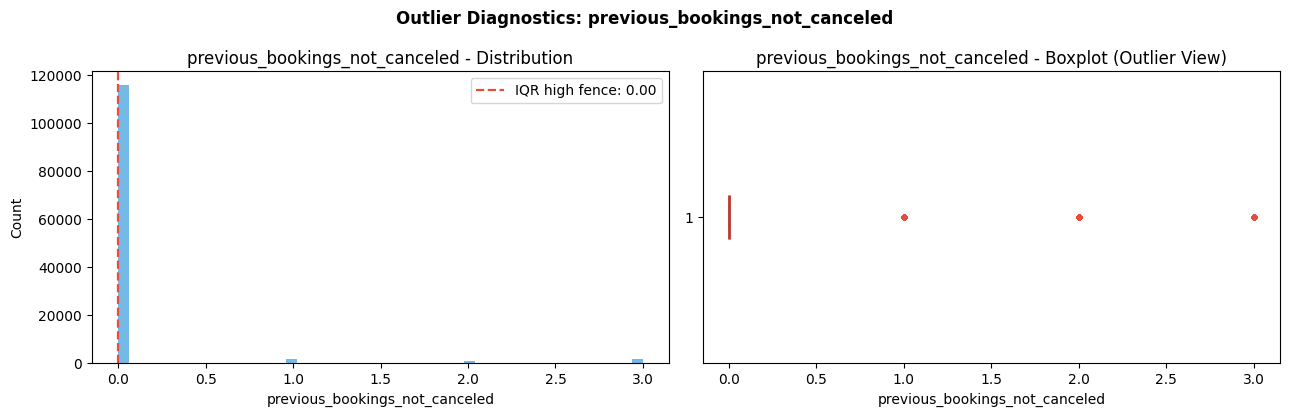

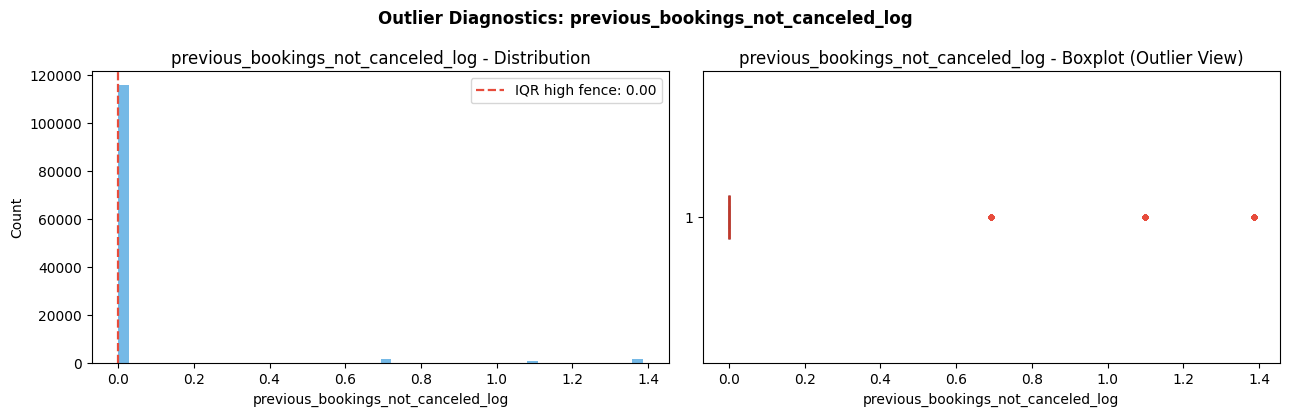

In [299]:
for col in outliers_fixed:
    if "log" not in col:  # non-log features
        visualize_outliers(df_clean, col, f"{col}_winsorized.png")
    else:
        visualize_outliers(df_clean, col, f"{col}_log.png")

Checking for duplicates

In [300]:
# checking for duplicates\
duplicates = df_clean.duplicated().sum()
print(f'Duplicate rows: {duplicates:,} ({duplicates/len(df_clean)*100:.2f}%)')

Duplicate rows: 31,985 (26.83%)


In [301]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after = len(df_clean)

print(f"Removed duplicates: {before - after:,}")
print(f"Rows after dedup: {after:,}")


Removed duplicates: 31,985
Rows after dedup: 87,224


In [302]:
print(f'Final cleaned dataset: {df_clean.shape}')

Final cleaned dataset: (87224, 57)


### Export final cleaned dataset

In [303]:
# saving this for baseline testing 
df_clean.to_csv('./data/hotel_bookings_cleaned.csv', index=False)